In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import math
from tqdm import tqdm

%run 01_vqvae.ipynb

input:  torch.Size([4, 1, 28, 28])
x_hat: torch.Size([4, 1, 28, 28])
z_e: torch.Size([4, 32, 7, 7])
z_q: torch.Size([4, 32, 7, 7])
idx: torch.Size([4, 7, 7])


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # scale to [-1, 1]
])

dataset    = torchvision.datasets.MNIST(root='../data', train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

In [3]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'using {device}')

using mps


epoch  1  loss 0.1728  codebook util 512/512


epoch  2  loss 0.0473  codebook util 512/512


epoch  3  loss 0.0381  codebook util 512/512


epoch  4  loss 0.0347  codebook util 512/512


epoch  5  loss 0.0324  codebook util 512/512


epoch  6  loss 0.0314  codebook util 512/512


epoch  7  loss 0.0306  codebook util 512/512


epoch  8  loss 0.0298  codebook util 512/512


epoch  9  loss 0.0294  codebook util 512/512


epoch 10  loss 0.0290  codebook util 512/512


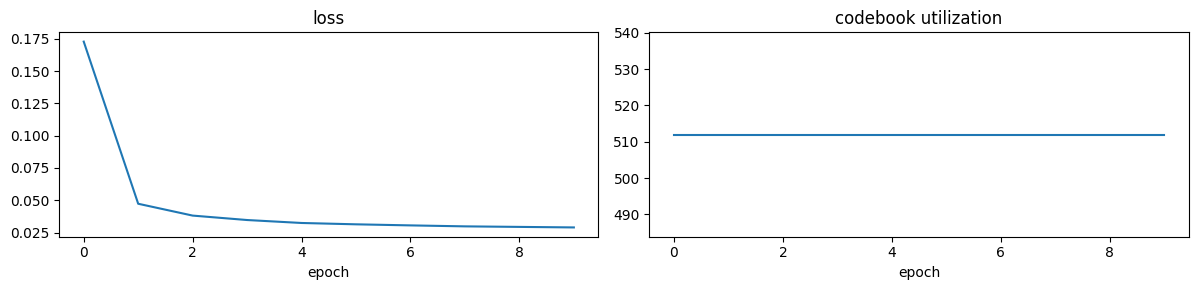

In [4]:
K = 512
d = 32
model     = VQVAE(K=K, d=d).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
loss_fn   = nn.MSELoss()

beta   = 0.25
epochs = 10
losses = []
codebook_utils = []

for epoch in range(epochs):
    epoch_loss = 0.0
    all_idx    = []
    pbar = tqdm(dataloader, desc=f'epoch {epoch+1}/{epochs}', leave=False)
    for x, _ in pbar:
        x     = x.to(device)
        x_hat, z_e, z_q, idx = model(x)
        l_recon  = loss_fn(x_hat, x)
        l_commit = loss_fn(z_q.detach(), z_e)   # codebook updated by EMA, not gradient
        loss     = l_recon + beta * l_commit

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        all_idx.append(idx.cpu())
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    avg_loss = epoch_loss / len(dataloader)
    util     = torch.cat([i.flatten() for i in all_idx]).unique().numel()
    losses.append(avg_loss)
    codebook_utils.append(util)
    print(f'epoch {epoch+1:2d}  loss {avg_loss:.4f}  codebook util {util}/{K}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.plot(losses);         ax1.set_title('loss');                 ax1.set_xlabel('epoch')
ax2.plot(codebook_utils); ax2.set_title('codebook utilization'); ax2.set_xlabel('epoch')
plt.tight_layout()
plt.show()

In [5]:
torch.save(model.cpu().state_dict(), '../data/vqvae_mnist.pt')
model.to(device)

VQVAE(
  (enc): Encoder(
    (conv1): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv2): Conv2d(32, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (act): ReLU()
  )
  (vq): VectorQuantizer()
  (dec): Decoder(
    (convt1): ConvTranspose2d(32, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (convt2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (act): ReLU()
  )
)

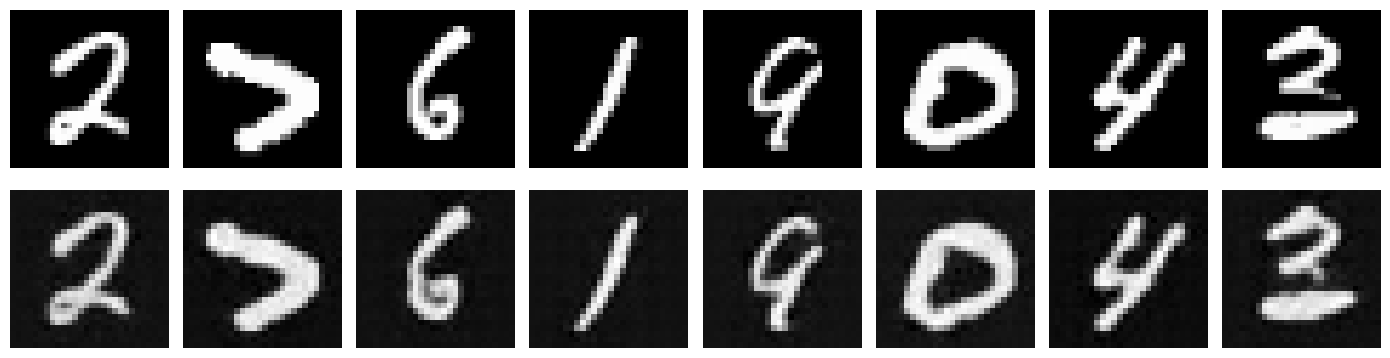

In [6]:
model.eval()
x_orig, _ = next(iter(dataloader))
x_orig = x_orig[:8].to(device)

with torch.no_grad():
    x_hat, _, _, _ = model(x_orig)

x_orig = (x_orig.cpu() + 1) / 2   # [-1,1] -> [0,1]
x_hat  = (x_hat.cpu()  + 1) / 2

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(x_orig[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_hat[i].squeeze(),  cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('original', fontsize=10)
axes[1, 0].set_ylabel('reconstructed', fontsize=10)
plt.tight_layout()
plt.show()